### Machine Learning Model

#### Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
heart = pd.read_csv('heart.csv')

In [9]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [11]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
X = heart.drop('HeartDisease' , axis = 1)

In [15]:
y = heart['HeartDisease']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [19]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

In [21]:
num_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')

In [23]:
cat_cols

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [25]:
preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ],
        remainder='passthrough'
    )

In [27]:
LGR = Pipeline([
   ('preprocessor', preprocessor),
   ('classifier', LogisticRegression(random_state=42))
])
LGR.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
print(f'Train R2 Score: {LGR.score(X_train, y_train)}')
print(f'Test R2 Score: {LGR.score(X_test, y_test)}')

Train R2 Score: 0.8692098092643051
Test R2 Score: 0.8532608695652174


In [31]:
train_rmse = RMSE(y_train, LGR.predict(X_train))
test_rmse = RMSE(y_test, LGR.predict(X_test))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 0.36
Test RMSE: 0.38


In [33]:
y_predLGR = LGR.predict(X_test)

In [35]:
precision = precision_score(y_test, y_predLGR, pos_label = 1)
recall = recall_score(y_test, y_predLGR, pos_label = 1)
f1 = f1_score(y_test,y_predLGR, pos_label = 1)
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.9000
Recall: 0.8411
F1 Score: 0.8696


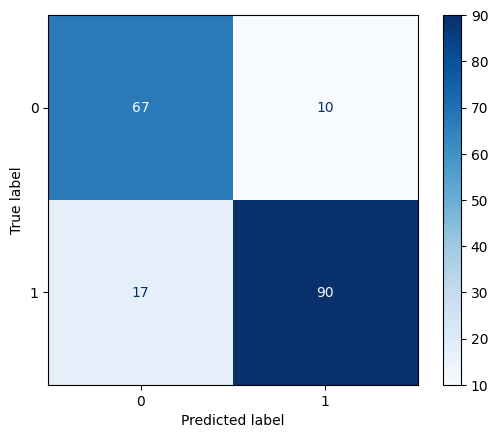

In [37]:
cm = confusion_matrix(y_test, y_predLGR)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.show()

In [38]:
probsLGR = LGR.predict_proba(X_test)

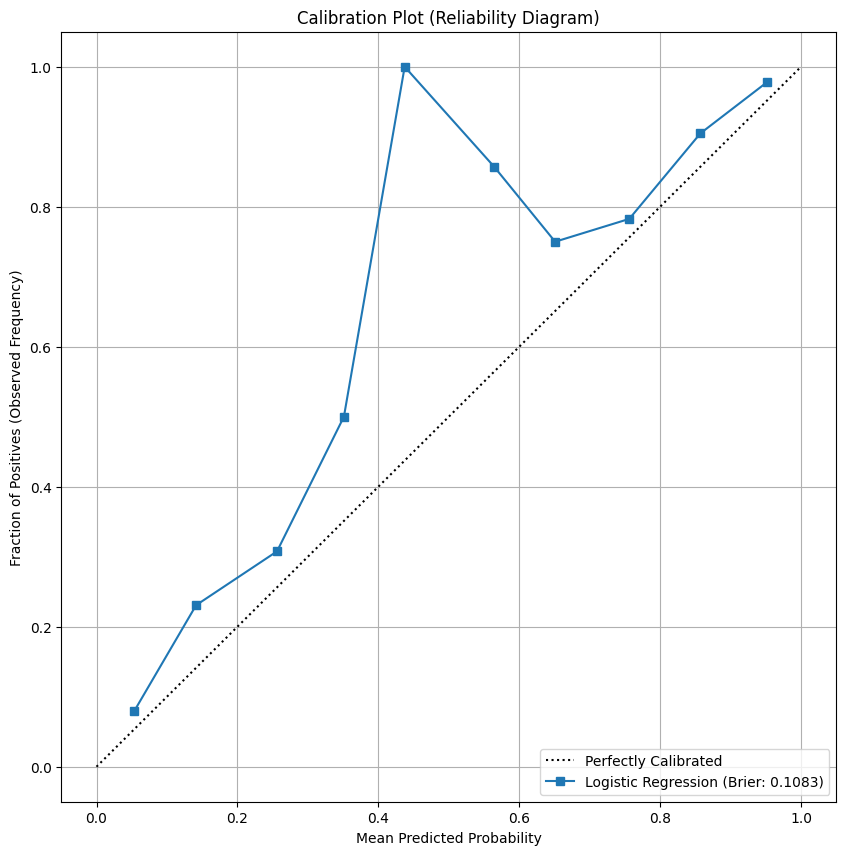

In [41]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, 
    probsLGR[:,1], 
    n_bins = 10
)

brier_score = brier_score_loss(y_test, probsLGR[:,1])

plt.figure(figsize=(10, 10))
ax1 = plt.subplot()

ax1.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')

ax1.plot(mean_predicted_value, fraction_of_positives, 's-', label=f'Logistic Regression (Brier: {brier_score:.4f})')

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (Observed Frequency)')
ax1.set_title('Calibration Plot (Reliability Diagram)')
ax1.legend(loc='lower right')
ax1.grid(True)

plt.show()

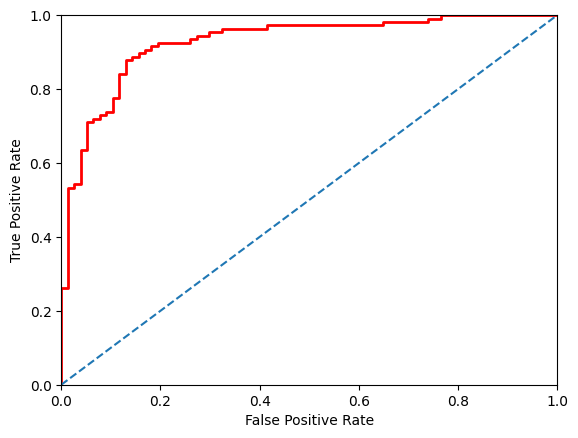

In [42]:
fpr, tpr, thresholds = roc_curve(y_test, probsLGR[:,1], pos_label = 1)
plt.plot(fpr, tpr, linewidth = 2, color = 'red')
plt.plot([0,1],[0,1], linestyle = '--')
plt.axis([0,1,0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [45]:
auc = roc_auc_score(y_test, probsLGR[:,1])
print(f'AUC: {auc:.4f}')

AUC: 0.9274


#### Linear Regression

In [48]:
dis_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [50]:
preprocessor2 = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('discretizer', KBinsDiscretizer(n_bins=5), dis_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ],
        remainder='passthrough'
    )

In [52]:
MLR = Pipeline([
	('pre', preprocessor2),
	('reg',LinearRegression())
])
MLR.fit(X_train,y_train)

D:\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
D:\Anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(


,steps,"[('pre', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('discretizer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
print(f'Train R2 Score: {MLR.score(X_train, y_train)}')
print(f'Test R2 Score: {MLR.score(X_test, y_test)}')

Train R2 Score: 0.5965747556009122
Test R2 Score: 0.5348635952609524


#### K Nearest Neighbour Classifier n = 5

In [57]:
KNN = Pipeline([
    ('pre', preprocessor),
   ('knn',KNeighborsClassifier(n_neighbors = 5))
])
KNN.fit(X_train,y_train)

,steps,"[('pre', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
print(f'Train R2 Score: {KNN.score(X_train, y_train)}')
print(f'Test R2 Score: {KNN.score(X_test, y_test)}')

Train R2 Score: 0.8828337874659401
Test R2 Score: 0.8641304347826086


In [60]:
param_grid = {'knn__n_neighbors' : np.arange(2,51)}
grid_search =  GridSearchCV(KNN, param_grid, cv = 5,n_jobs = -1)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'knn__n_neighbors': 5}


In [61]:
y_predKNN = KNN.predict(X_test)

In [62]:
train_rmse = RMSE(y_train, KNN.predict(X_train))
test_rmse = RMSE(y_test, KNN.predict(X_test))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 0.34
Test RMSE: 0.37


In [63]:
precision = precision_score(y_test, y_predKNN, pos_label = 1)
recall = recall_score(y_test, y_predKNN, pos_label = 1)
f1 = f1_score(y_test,y_predKNN, pos_label = 1)
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.9100
Recall: 0.8505
F1 Score: 0.8792


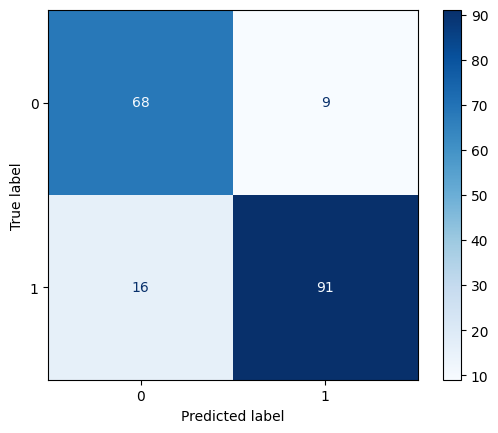

In [65]:
cm = confusion_matrix(y_test, y_predKNN)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.show()

In [76]:
probsKNN = KNN.predict_proba(X_test)

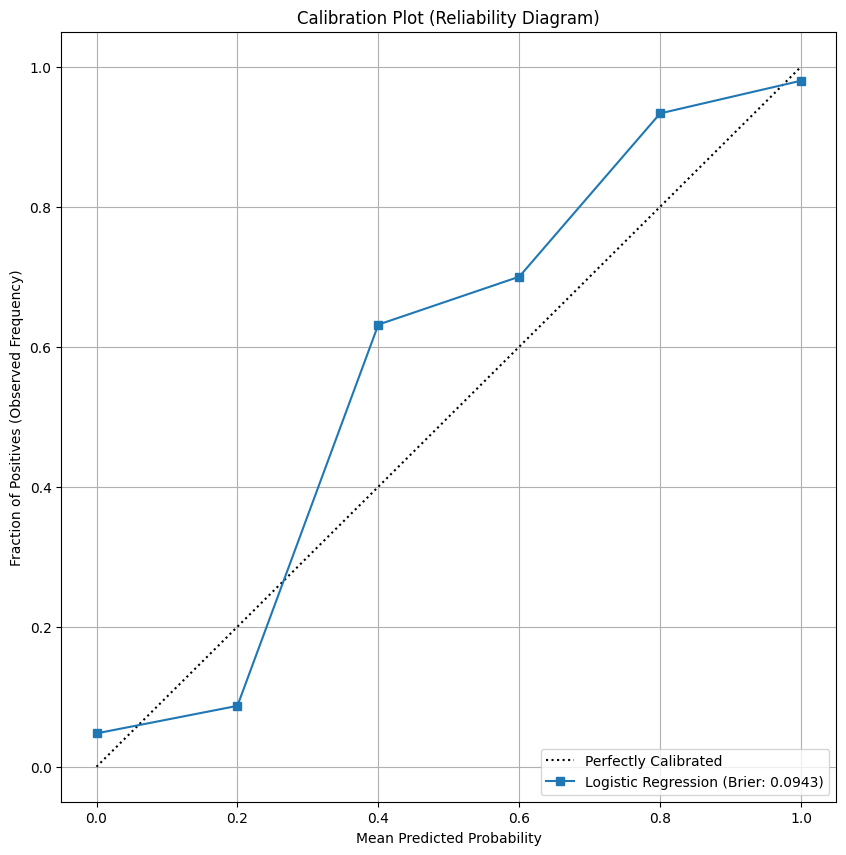

In [129]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, 
    probsKNN[:,1], 
    n_bins = 10
)

brier_score = brier_score_loss(y_test, probsKNN[:,1])

plt.figure(figsize=(10, 10))
ax1 = plt.subplot()

ax1.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')

ax1.plot(mean_predicted_value, fraction_of_positives, 's-', label=f'Logistic Regression (Brier: {brier_score:.4f})')

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (Observed Frequency)')
ax1.set_title('Calibration Plot (Reliability Diagram)')
ax1.legend(loc='lower right')
ax1.grid(True)

plt.show()

#### Using GridSearchCV result to plot

In [ ]:
param_grid = {'knn__n_neighbors' : np.arange(2,51)}
grid_search =  GridSearchCV(KNN, param_grid, cv = 5,n_jobs = -1)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

In [118]:
results = pd.DataFrame(grid_search.cv_results_)

In [116]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015698,0.001152,0.204823,0.018765,2,{'knn__n_neighbors': 2},0.795918,0.823129,0.809524,0.741497,0.780822,0.790178,0.028108,49
1,0.015220,0.003726,0.151243,0.118135,3,{'knn__n_neighbors': 3},0.870748,0.897959,0.850340,0.816327,0.849315,0.856938,0.026924,48
2,0.014460,0.002351,0.009793,0.001458,4,{'knn__n_neighbors': 4},0.870748,0.877551,0.836735,0.823129,0.876712,0.856975,0.022618,46
3,0.012413,0.001149,0.008658,0.000701,5,{'knn__n_neighbors': 5},0.884354,0.897959,0.850340,0.823129,0.883562,0.867869,0.027322,1
4,0.016795,0.005222,0.009353,0.002265,6,{'knn__n_neighbors': 6},0.897959,0.877551,0.836735,0.802721,0.883562,0.859706,0.035002,29
5,0.015258,0.003067,0.012607,0.004448,7,{'knn__n_neighbors': 7},0.891156,0.891156,0.870748,0.809524,0.876712,0.867859,0.030250,2
6,0.018838,0.004612,0.010199,0.003094,8,{'knn__n_neighbors': 8},0.891156,0.863946,0.850340,0.816327,0.876712,0.859696,0.025557,31
7,0.019293,0.005342,0.010696,0.002173,9,{'knn__n_neighbors': 9},0.884354,0.884354,0.857143,0.795918,0.876712,0.859696,0.033406,31
8,0.016248,0.003134,0.008849,0.000903,10,{'knn__n_neighbors': 10},0.884354,0.877551,0.857143,0.802721,0.883562,0.861066,0.030788,18
9,0.014361,0.002478,0.009148,0.002332,11,{'knn__n_neighbors': 11},0.884354,0.884354,0.850340,0.809524,0.876712,0.861057,0.028639,20


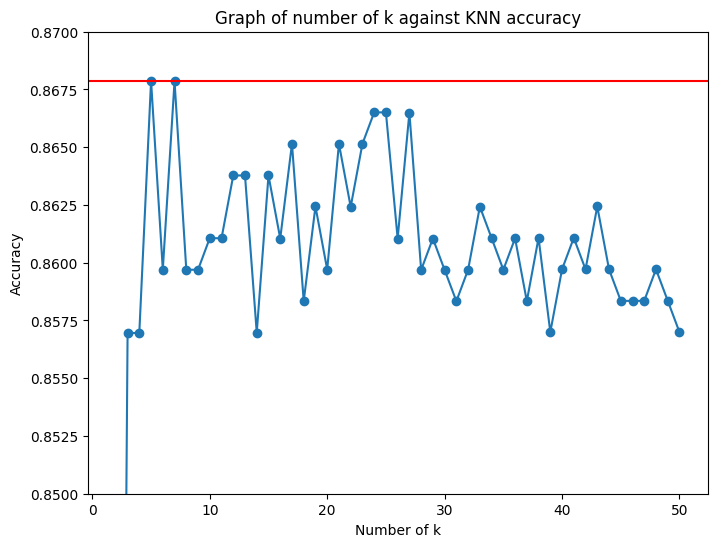

In [192]:
plt.figure(figsize=(8,6))
plt.plot(range(2,51), results['mean_test_score'],'-o')
plt.xlabel('Number of k')
plt.ylabel('Accuracy')
plt.ylim(0.85,0.87)
plt.title('Graph of number of k against KNN accuracy') 
plt.axhline(0.867869,color = 'red')
plt.show()

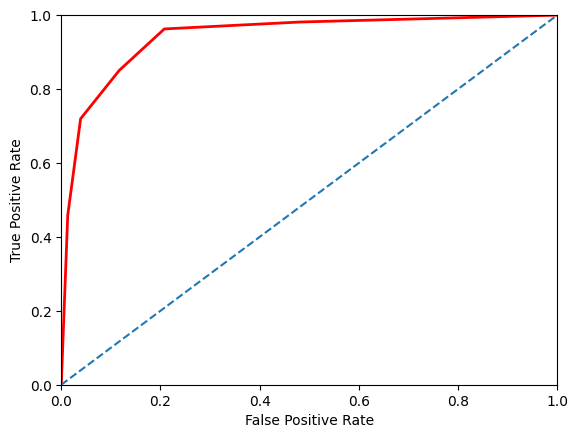

In [77]:
fpr, tpr, thresholds = roc_curve(y_test, probsKNN[:,1], pos_label = 1)
plt.plot(fpr, tpr, linewidth = 2, color = 'red')
plt.plot([0,1],[0,1], linestyle = '--')
plt.axis([0,1,0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [78]:
auc = roc_auc_score(y_test, probsKNN[:,1])
print(f'AUC: {auc:.4f}')

AUC: 0.9416
